# Orbit Wars - Observation Explorer (mlp_v1)

Quick exploratory notebook for the Orbit Wars env.
Runs 4 random agents and inspects how the observation evolves over 500 turns.

Useful for designing the encoder/feature pipeline for mlp_v1.


In [1]:
from kaggle_environments import make
import pandas as pd


Loading environment cabt failed: dlopen(/Users/agent/dev/kaggle-orbit-wars/.venv/lib/python3.13/site-packages/kaggle_environments/envs/cabt/cg/libcg.so, 0x0006): tried: '/Users/agent/dev/kaggle-orbit-wars/.venv/lib/python3.13/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (slice is not valid mach-o file), '/System/Volumes/Preboot/Cryptexes/OS/Users/agent/dev/kaggle-orbit-wars/.venv/lib/python3.13/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (no such file), '/Users/agent/dev/kaggle-orbit-wars/.venv/lib/python3.13/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (slice is not valid mach-o file)
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 16.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[k

## Helpers

In [2]:
def _summarize_field_value(v):
    """Inspect any obs field and return (dtype, shape, length)."""
    shape = None
    length = None
    dtype = type(v).__name__

    if hasattr(v, 'shape'):
        try:
            shape = tuple(v.shape)
        except Exception:
            shape = None

    if hasattr(v, '__len__'):
        try:
            length = len(v)
        except Exception:
            length = None

    if length is None and shape is not None and len(shape) > 0:
        length = shape[0]
    if length is None:
        length = 1

    return dtype, shape, length


def _get_player0_observation(obs):
    """Orbit Wars observations may be per-agent dicts or a dict with a 'players' list."""
    if isinstance(obs, dict) and 'players' in obs and isinstance(obs['players'], (list, tuple)) and obs['players']:
        return obs['players'][0]
    if isinstance(obs, (list, tuple)) and obs:
        return obs[0]
    return obs


## Run env (4 random agents)

In [3]:
env = make('orbit_wars', debug=True)
print(f'Environment: {env.name} v{env.version}')
print(f'Players: {env.specification.agents}')
print(f'Max steps: {env.configuration.episodeSteps}')

env.run(['random', 'random', 'random', 'random'])
print(f'completed: {len(env.steps)} steps recorded')


Environment: orbit_wars v1.0.9
Players: [2, 4]
Max steps: 500
completed: 500 steps recorded


## Inspect observation schema

In [4]:
# Look at one observation in detail to learn the schema.
obs0 = env.steps[0][0].observation
print('keys:', sorted(obs0.keys()))
print()
for k, v in obs0.items():
    dtype, shape, length = _summarize_field_value(v)
    print(f'{k:25s}  dtype={dtype:15s}  shape={shape}  len={length}')


keys: ['angular_velocity', 'comet_planet_ids', 'comets', 'fleets', 'initial_planets', 'next_fleet_id', 'planets', 'player', 'remainingOverageTime', 'step']

remainingOverageTime       dtype=int              shape=None  len=1
step                       dtype=int              shape=None  len=1
planets                    dtype=list             shape=None  len=0
fleets                     dtype=list             shape=None  len=0
player                     dtype=int              shape=None  len=1
angular_velocity           dtype=int              shape=None  len=1
initial_planets            dtype=list             shape=None  len=0
next_fleet_id              dtype=int              shape=None  len=1
comets                     dtype=list             shape=None  len=0
comet_planet_ids           dtype=list             shape=None  len=0


## Per-step observation counts (DataFrame)

In [5]:
# Track how key counts evolve over 500 turns from player 0's POV.
agent_idx = 0
rows = []
for step_idx in range(len(env.steps)):
    obs = env.steps[step_idx][agent_idx].observation
    rows.append({
        'step': step_idx,
        'player': agent_idx,
        'angular_velocity': obs['angular_velocity'],
        'len_comet_planet_ids': len(obs['comet_planet_ids']),
        'len_planets': len(obs['planets']),
        'len_initial_planets': len(obs.get('initial_planets') or []),
        'len_fleets': len(obs['fleets']),
        'len_comets': len(obs['comets']),
    })

df = pd.DataFrame(rows)
df.head(20)


,step,player,angular_velocity,len_comet_planet_ids,len_planets,len_fleets,len_comets
0,0,0,0.000000,0,0,0,0
1,1,0,0.042724,0,36,0,0
2,2,0,0.042724,0,36,0,0
3,3,0,0.042724,0,36,0,0
4,4,0,0.042724,0,36,0,0
5,5,0,0.042724,0,36,0,0
6,6,0,0.042724,0,36,0,0
7,7,0,0.042724,0,36,0,0
8,8,0,0.042724,0,36,0,0
9,9,0,0.042724,0,36,0,0


## Summary stats

In [6]:
# Aggregate stats — how the env state varies over the episode.
print('---summary stats---')
print(df.describe())
print()
print('---fleets count distribution---')
print(df['len_fleets'].value_counts().sort_index().head(20))


---summary stats---
             step  player  angular_velocity  len_comet_planet_ids  \
count  500.000000   500.0        500.000000            500.000000   
mean   249.500000     0.0          0.042639              1.288000   
std    144.481833     0.0          0.001911              1.870844   
min      0.000000     0.0          0.000000              0.000000   
25%    124.750000     0.0          0.042724              0.000000   
50%    249.500000     0.0          0.042724              0.000000   
75%    374.250000     0.0          0.042724              4.000000   
max    499.000000     0.0          0.042724              4.000000   

       len_planets  len_fleets  len_comets  
count   500.000000  500.000000  500.000000  
mean     37.216000   20.036000    0.322000  
std       2.505574   10.008148    0.467711  
min       0.000000    0.000000    0.000000  
25%      36.000000   10.000000    0.000000  
50%      36.000000   21.000000    0.000000  
75%      40.000000   29.000000    1.000000 

## Plots over the episode

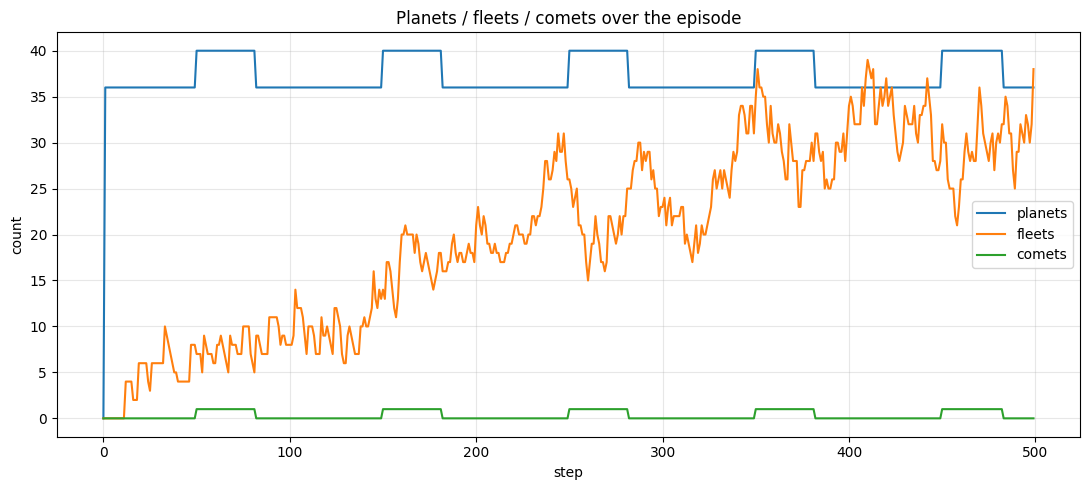

In [7]:
# All four counts on one chart for direct comparison.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df['step'], df['len_planets'], label='planets', color='tab:blue')
ax.plot(df['step'], df['len_initial_planets'], label='initial_planets', color='tab:purple', linestyle='--')
ax.plot(df['step'], df['len_fleets'], label='fleets', color='tab:orange')
ax.plot(df['step'], df['len_comets'], label='comets', color='tab:green')
ax.set_xlabel('step')
ax.set_ylabel('count')
ax.set_title('Planets / initial_planets / fleets / comets over the episode')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Sample comet entry positions across 50 games

In [ ]:
# Sample comet entry points (x, y) across N games.
# obs["comets"] is a list whose only element is the active wave (or empty
# between waves). The same planet_ids [28,29,30,31] are recycled across all
# 5 waves, so dedup by id doesn't work — instead use path_index == 0 as the
# unambiguous spawn marker. 5 waves × 4 comets = 20 entries / game.
N_GAMES = 10
entries = []
for game_idx in range(N_GAMES):
    env = make("orbit_wars", configuration={"seed": game_idx}, debug=False)
    env.run(["random", "random", "random", "random"])
    for step_idx in range(len(env.steps)):
        obs = env.steps[step_idx][0].observation
        for comet_group in obs.get("comets") or []:
            if comet_group.get("path_index") != 0:
                continue
            paths = comet_group.get("paths") or []
            pids = comet_group.get("planet_ids") or []
            for i, path in enumerate(paths):
                if not path:
                    continue
                pid = pids[i] if i < len(pids) else -1
                x, y = path[0][0], path[0][1]
                entries.append({
                    "game": game_idx,
                    "pid": pid,
                    "step_seen": step_idx,
                    "x": x,
                    "y": y,
                })
    if (game_idx + 1) % 10 == 0:
        print(f"  game {game_idx + 1}/{N_GAMES}: {len(entries)} entries so far")

entries_df = pd.DataFrame(entries)
print(f"\ntotal entries: {len(entries_df)}")
print(f"mean entries / game: {len(entries_df) / N_GAMES:.1f}")
print(f"spawn steps observed: {sorted(entries_df['step_seen'].unique().tolist())}")
entries_df.head(12)


SyntaxError: unterminated f-string literal (detected at line 31) (1029668075.py, line 31)

## Scatter of entry points on the 100×100 board

In [ ]:
# Scatter the comet entry points on the 100x100 board.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(entries_df['x'], entries_df['y'], s=14, alpha=0.5, color='tab:green', edgecolor='none')
# Sun at (50, 50) for reference
ax.add_patch(plt.Circle((50, 50), 10, color='tab:orange', alpha=0.25, label='sun'))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Comet entry positions over {N_GAMES} games (n={len(entries_df)})')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Debug: comet group structure at spawn steps

In [ ]:
# Debug: inspect obs['comets'] at the canonical spawn steps for one game.
debug_env = make('orbit_wars', configuration={'seed': 0}, debug=False)
debug_env.run(['random', 'random', 'random', 'random'])
for spawn_step in [50, 150, 250, 350, 450]:
    if spawn_step >= len(debug_env.steps):
        continue
    obs = debug_env.steps[spawn_step][0].observation
    cg = obs.get('comets') or []
    print(f'step {spawn_step}: len(comets)={len(cg)}')
    for i, group in enumerate(cg):
        pids = group.get('planet_ids') or []
        paths = group.get('paths') or []
        path_len_sample = len(paths[0]) if paths and paths[0] else 0
        first_pos = paths[0][0] if paths and paths[0] else None
        print(f'  group {i}: |pids|={len(pids)}  pids={pids[:6]}{"..." if len(pids) > 6 else ""}  '
              f'|paths|={len(paths)}  path[0] len={path_len_sample}  path[0][0]={first_pos}')


In [ ]:
# Debug: inspect obs['comets'] at the canonical spawn steps for one game.
debug_env = make('orbit_wars', configuration={'seed': 0}, debug=False)
debug_env.run(['random', 'random', 'random', 'random'])

max_comet_groups = 0
for spawn_step in range(500):
    if spawn_step >= len(debug_env.steps):
        continue
    obs = debug_env.steps[spawn_step][0].observation
    cg = obs.get('comets') or []
    max_comet_groups = max(max_comet_groups, len(cg))
    print(f'step {spawn_step}: len(comets)={len(cg)}')

    
print(f'max comet groups: {max_comet_groups}')